# Notebook 01 — Dispersive Readout: Qubit Physics

**Project 2 — Superconducting Qubit Readout Signal Processing Pipeline**

---

## Theory

In the **dispersive regime** ($g \ll |\omega_q - \omega_r|$), the Jaynes-Cummings Hamiltonian reduces to:

$$H_{\rm eff}/\hbar = (\omega_r + \chi \sigma_z)\,a^\dagger a \;+\; \frac{\omega_q}{2}\sigma_z$$

The cavity resonance shifts by $\pm\chi$ depending on the qubit state — this is the **dispersive shift** that enables quantum non-demolition readout.

| Qubit state | Cavity frequency | Drive detuning $\delta$ |
|:---:|:---:|:---:|
| $|0\rangle$ | $\omega_r + \chi$ | $\omega_d - (\omega_r + \chi)$ |
| $|1\rangle$ | $\omega_r - \chi$ | $\omega_d - (\omega_r - \chi)$ |

In the rotating frame at $\omega_d$, the classical cavity field obeys:

$$\frac{d\alpha}{dt} = -\left(\frac{\kappa}{2} + i\delta_s\right)\alpha + \varepsilon$$

with steady state $\alpha_{\rm ss} = \varepsilon\,/\,(\kappa/2 + i\delta_s)$.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from src.transmon import (
    TransmonParams, DEFAULT_PARAMS, simulate_shots,
    snr_db, steady_state_analytical, print_hamiltonian)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

In [2]:
# Display physical parameters and Hamiltonian
p = DEFAULT_PARAMS
print_hamiltonian(p)
print()
print(f"Drive frequency      : {p.omega_d/(2*np.pi)/1e9:.3f} GHz  (at bare cavity)")
print(f"Noise sigma          : {p.noise_sigma}")
print(f"Readout window       : {p.t_end*1e6:.1f} µs  ({p.n_time} samples)")


  Dispersive Hamiltonian (rotating wave approximation):
  H/ℏ = (ωr + χ·σz)·a†a  +  (ωq/2)·σz

  Parameters:
    ωr/2π  = 6.50 GHz  (bare cavity)
    ωq/2π  = 5.00 GHz  (qubit)
    χ/2π   = 1.00 MHz  (dispersive shift)
    κ/2π   = 2.00 MHz  (cavity linewidth)

  Dressed cavity frequencies:
    |0⟩  →  (ωr + χ)/2π = 6.5010 GHz
    |1⟩  →  (ωr − χ)/2π = 6.4990 GHz

Drive frequency      : 6.500 GHz  (at bare cavity)
Noise sigma          : 0.15
Readout window       : 1.0 µs  (512 samples)


## 1.1 Noise-free cavity field buildup

Solving $d\alpha/dt = -(\kappa/2 + i\delta_s)\alpha + \varepsilon$ with $\alpha(0)=0$.

In [3]:
from src.transmon import simulate_cavity

alpha_0, t = simulate_cavity(0)
alpha_1, _ = simulate_cavity(1)

ss0, ss1 = steady_state_analytical()
print(f"Steady-state |0>: {ss0:.4f}   (I={ss0.real:.3f}, Q={ss0.imag:.3f})")
print(f"Steady-state |1>: {ss1:.4f}   (I={ss1.real:.3f}, Q={ss1.imag:.3f})")
print(f"Separation |a0-a1| = {abs(ss0-ss1):.4f}")

Steady-state |0>: 0.5000+0.5000j   (I=0.500, Q=0.500)
Steady-state |1>: 0.5000-0.5000j   (I=0.500, Q=-0.500)
Separation |a0-a1| = 1.0000


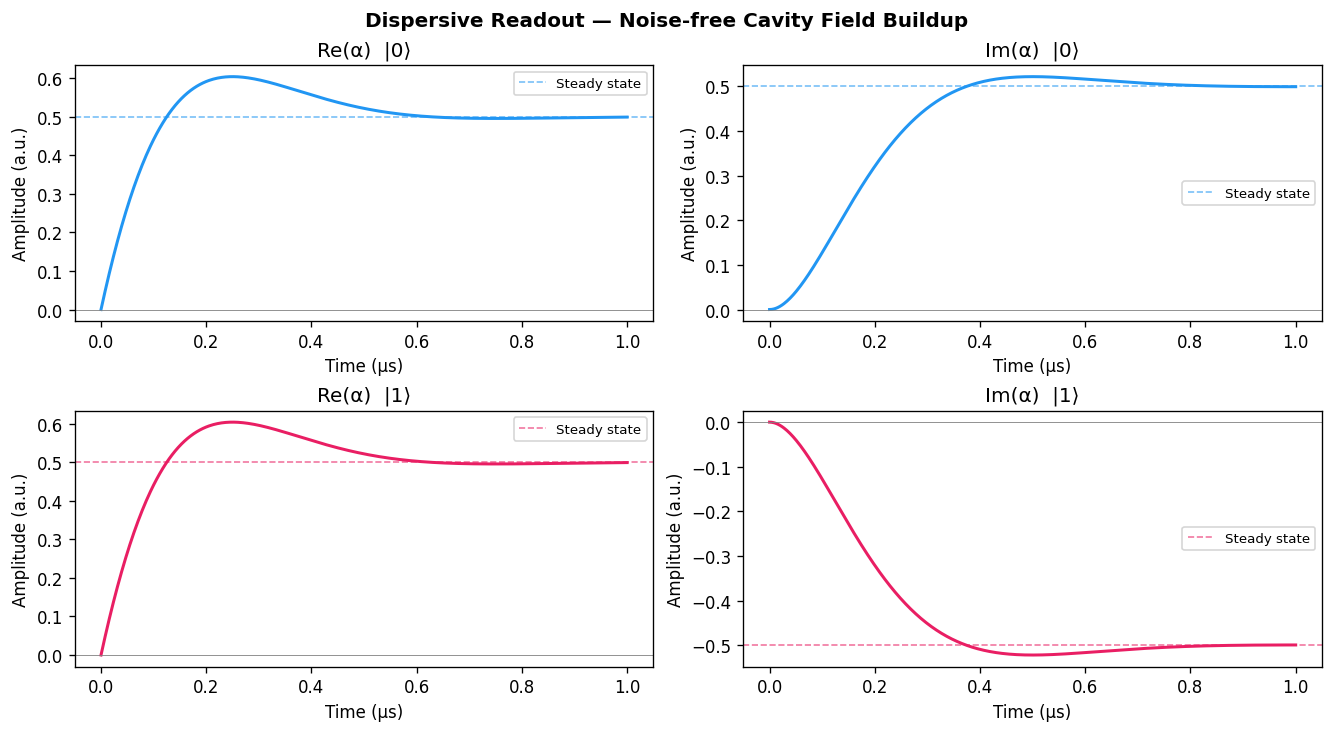

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6), constrained_layout=True)
fig.suptitle("Dispersive Readout — Noise-free Cavity Field Buildup", fontsize=12, fontweight="bold")
t_us = t * 1e6

config = [
    ("Re(α)  |0⟩", alpha_0.real, "#2196F3"),
    ("Im(α)  |0⟩", alpha_0.imag, "#2196F3"),
    ("Re(α)  |1⟩", alpha_1.real, "#E91E63"),
    ("Im(α)  |1⟩", alpha_1.imag, "#E91E63"),
]
for ax, (title, trace, col) in zip(axes.flat, config):
    ax.plot(t_us, trace, color=col, linewidth=1.8)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_xlabel("Time (µs)"); ax.set_ylabel("Amplitude (a.u.)")
    ax.set_title(title)
    # Mark steady state
    if "|0" in title and "Re" in title: ss_val = ss0.real
    elif "|0" in title: ss_val = ss0.imag
    elif "Re" in title: ss_val = ss1.real
    else: ss_val = ss1.imag
    ax.axhline(ss_val, color=col, linewidth=1, linestyle="--", alpha=0.6, label="Steady state")
    ax.legend(fontsize=8)
plt.show()

## 1.2 Monte-Carlo shot simulation (1000 shots × 2 states)

AWGN is added to each shot independently, modelling amplifier noise and quantum vacuum fluctuations.

In [5]:
data    = simulate_shots(n_shots=1000, rng_seed=42)
shots_0 = data["shots_0"]   # (1000, 512) complex
shots_1 = data["shots_1"]

snr = snr_db(alpha_0, alpha_1, p.noise_sigma)
print(f"Single-shot SNR at steady state: {snr:.2f} dB")

Single-shot SNR at steady state: 10.44 dB


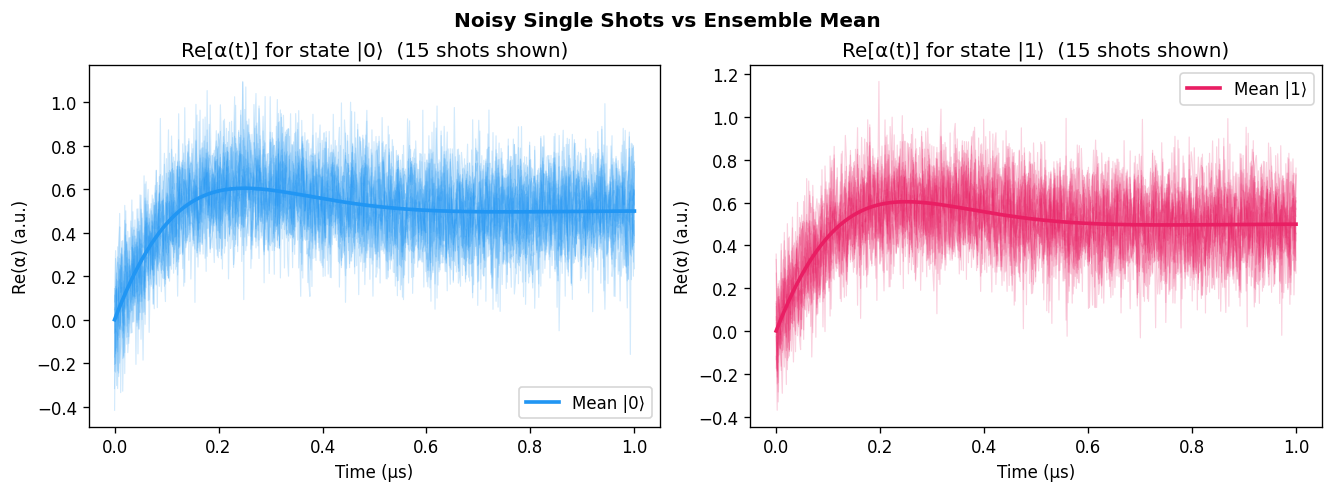

In [6]:
# Plot: few individual shots + ensemble mean
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
fig.suptitle("Noisy Single Shots vs Ensemble Mean", fontsize=12, fontweight="bold")

n_ex = 15
for ax, (shots, alpha, col, label) in zip(axes, [
    (shots_0, alpha_0, "#2196F3", "|0⟩"),
    (shots_1, alpha_1, "#E91E63", "|1⟩"),
]):
    ax.plot(t_us, shots[:n_ex].real.T, color=col, alpha=0.2, linewidth=0.7)
    ax.plot(t_us, alpha.real, color=col, linewidth=2.2, label=f"Mean {label}")
    ax.set_xlabel("Time (µs)"); ax.set_ylabel("Re(α) (a.u.)")
    ax.set_title(f"Re[α(t)] for state {label}  ({n_ex} shots shown)")
    ax.legend()
plt.show()

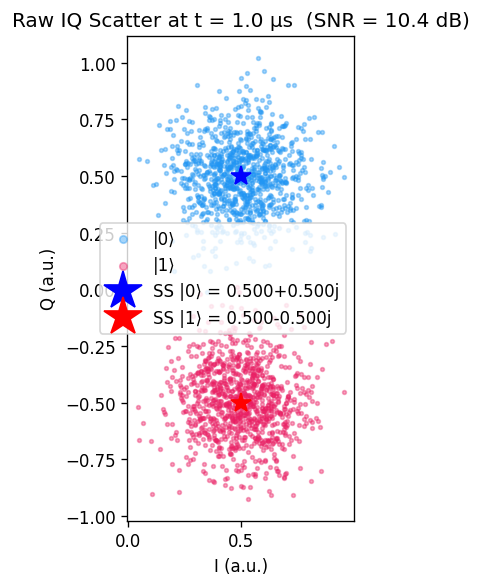

In [7]:
# IQ scatter at t = t_end (last sample, before integration)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(shots_0[:, -1].real, shots_0[:, -1].imag,
           s=5, alpha=0.4, color="#2196F3", label="|0⟩", rasterized=True)
ax.scatter(shots_1[:, -1].real, shots_1[:, -1].imag,
           s=5, alpha=0.4, color="#E91E63", label="|1⟩", rasterized=True)
ax.plot(ss0.real, ss0.imag, "b*", markersize=12, label=f"SS |0⟩ = {ss0:.3f}")
ax.plot(ss1.real, ss1.imag, "r*", markersize=12, label=f"SS |1⟩ = {ss1:.3f}")
ax.set_xlabel("I (a.u.)"); ax.set_ylabel("Q (a.u.)")
ax.set_title(f"Raw IQ Scatter at t = {p.t_end*1e6:.1f} µs  (SNR = {snr:.1f} dB)")
ax.legend(markerscale=2); ax.set_aspect("equal")
plt.tight_layout(); plt.show()